# EDA — Validating the model's assumptions

Four checks requested after the `slack_min` importance discussion:

1. **Is `slack_min` knowable at accept time?** — is `time_window_end` a preset
   deadline, or does it depend on the pickup? Plot pickup vs window_end.
2. **Target distribution** — histogram, log scale, p95/p99; is the heavy tail
   operational (longer windows → longer pickups)?
3. **Error by duration bucket** — test MAE broken out by target decile.
4. **Cross-courier prediction spread** — for fixed orders, how much do predictions
   vary across couriers? If the spread is tiny the cost-matrix columns are
   near-constant and the assignment has nothing to optimize.

Run with the `dispatch (.venv)` kernel.

In [4]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
import sys, pathlib
_root = pathlib.Path.cwd()                         # locate the project's src/ regardless of cwd
while not (_root / "src" / "dispatch").exists() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from dispatch.config import load_config
from dispatch.data import load_clean
from dispatch.features import add_courier_history, build_features
from dispatch.model import load_model
from dispatch.snapshot import reconstruct_at
from dispatch.assignment import build_pair_frame

plt.rcParams["axes.grid"] = True
cfg = load_config(); model = load_model(cfg); TARGET = cfg.target_name
df = load_clean(cfg)                       # full cleaned dataset
df, gavg = add_courier_history(df, cfg)
wd = (df.time_window_end - df.time_window_start).dt.total_seconds() / 60
y = df[TARGET]
print(f"rows={len(df):,}  global_avg={gavg:.1f}  baseline test MAE={model.metadata['test_metrics']['mae']:.1f}")

rows=1,408,240  global_avg=198.7  baseline test MAE=47.5


## Q1 — Is `slack_min` knowable at accept time?

`slack_min = window_end − accept_time`. It is only point-in-time valid if
`window_end` is fixed when the order is created (a business deadline) rather than
derived from the pickup. Evidence: window length should be a small set of preset
values landing on round clock times, and pickups should happen *inside* the window
(before `window_end`), not be defined by it.

window_duration_min — value counts (top):
120.0     1385027
60.0         9230
899.0        6018
1841.0         27

window_end falls on a round hour (minute==0): 96.2%
pickup − window_end (min):  median=-88  | picked BEFORE window_end=97.5%  | within ±15min of end=4.6%


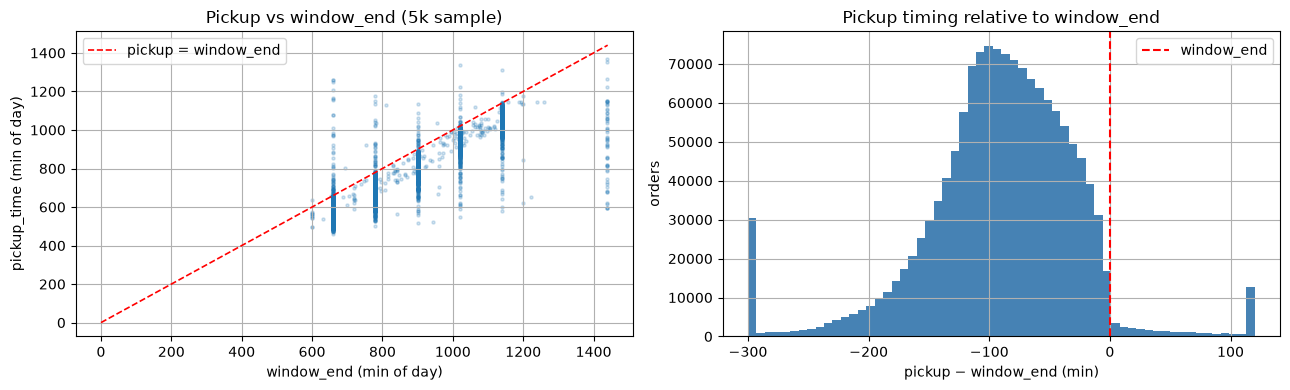

In [5]:
print("window_duration_min — value counts (top):")
print(wd.value_counts().head(4).to_string())
print(f"\nwindow_end falls on a round hour (minute==0): {(df.time_window_end.dt.minute==0).mean():.1%}")
delta = (df.pickup_time - df.time_window_end).dt.total_seconds() / 60
print(f"pickup − window_end (min):  median={delta.median():.0f}  "
      f"| picked BEFORE window_end={(delta<=0).mean():.1%}  | within ±15min of end={(delta.abs()<=15).mean():.1%}")

samp = df.sample(5000, random_state=0)
xe = samp.time_window_end.dt.hour*60 + samp.time_window_end.dt.minute
yp = samp.pickup_time.dt.hour*60 + samp.pickup_time.dt.minute
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].scatter(xe, yp, s=5, alpha=0.2)
ax[0].plot([0, 1440], [0, 1440], 'r--', lw=1.2, label="pickup = window_end")
ax[0].set(xlabel="window_end (min of day)", ylabel="pickup_time (min of day)",
          title="Pickup vs window_end (5k sample)"); ax[0].legend()
ax[1].hist(delta.clip(-300, 120), bins=60, color="steelblue")
ax[1].axvline(0, color="r", ls="--", label="window_end")
ax[1].set(xlabel="pickup − window_end (min)", ylabel="orders",
          title="Pickup timing relative to window_end"); ax[1].legend()
plt.tight_layout(); plt.show()

**Finding.** `window_duration` is **120 min for 98.3%** of orders (a few 60-min
and 899-min), and `window_end` lands on a **round hour 96%** of the time — these are
preset deadlines, not pickup-derived. **97.5% of pickups happen *before*
`window_end`** (median 88 min before), so pickups sit inside a fixed window; they do
**not** cluster at/just past it. ⇒ `slack_min` is fully knowable at accept time —
**not leakage.**

## Q2 — Target distribution and the heavy tail

p50 = 123 min
p95 = 555 min
p99 = 1584 min

corr(slack, target)          = 0.894
corr(window_duration, target) = 0.074


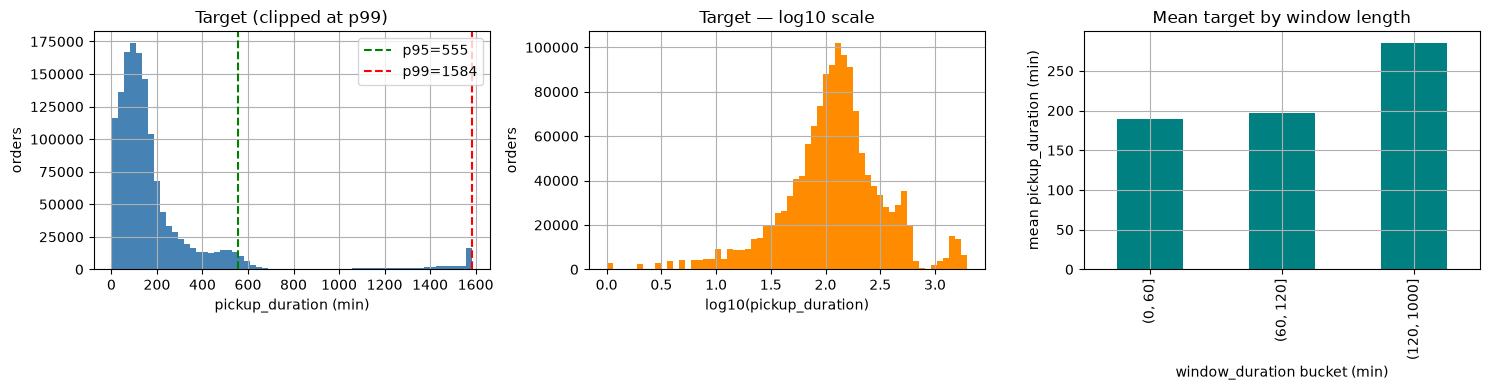

In [6]:
for q in (.5, .95, .99):
    print(f"p{int(q*100)} = {y.quantile(q):.0f} min")
slack = (df.time_window_end - df.accept_time).dt.total_seconds() / 60
print(f"\ncorr(slack, target)          = {np.corrcoef(slack, y)[0,1]:.3f}")
print(f"corr(window_duration, target) = {np.corrcoef(wd, y)[0,1]:.3f}")

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(y.clip(upper=y.quantile(.99)), bins=60, color="steelblue")
for q, c in [(.95, "g"), (.99, "r")]:
    ax[0].axvline(y.quantile(q), color=c, ls="--", label=f"p{int(q*100)}={y.quantile(q):.0f}")
ax[0].set(title="Target (clipped at p99)", xlabel="pickup_duration (min)", ylabel="orders"); ax[0].legend()
ax[1].hist(np.log10(y), bins=60, color="darkorange")
ax[1].set(title="Target — log10 scale", xlabel="log10(pickup_duration)", ylabel="orders")
gm = y.groupby(pd.cut(wd, [0, 60, 120, 1000])).mean()
gm.plot.bar(ax=ax[2], color="teal")
ax[2].set(title="Mean target by window length", ylabel="mean pickup_duration (min)", xlabel="window_duration bucket (min)")
plt.tight_layout(); plt.show()

**Finding.** Strong right skew (p50=123, p95=555, p99=1584 min); near-lognormal
on the log axis. `slack` correlates **0.89** with the target while raw window length
barely does (0.07) — what matters is *time remaining in the window at accept*. And
**longer windows → longer pickups** (mean ~197 min for 2-h windows vs ~353 for the
long ones): couriers spend the slack they're given. The tail is **operational**, not
a data artifact.

## Q3 — Error by target decile

            n  y_mean   mae  mape_%
decile                             
0       28464    16.9  59.3   351.8
1       28250    44.9  42.5    94.6
2       27312    68.6  33.2    48.4
3       29159    90.6  29.1    32.1
4       27178   111.8  29.1    26.0
5       27735   134.3  33.2    24.7
6       28151   161.1  41.8    26.0
7       27936   202.7  51.9    25.6
8       27893   308.7  62.8    20.3
9       28007   828.5  92.2    11.1

overall test MAE = 47.54


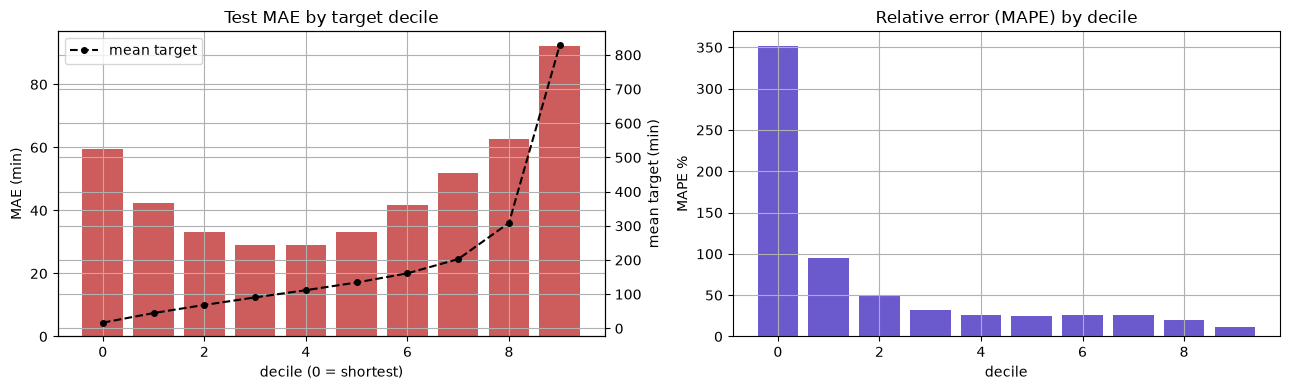

In [7]:
test = df.accept_time.dt.month >= cfg.test_start_month
X_te = build_features(df[test], cfg); y_te = y[test].to_numpy()
pred = model.predict(X_te); ae = np.abs(pred - y_te)
dec = pd.qcut(y_te, 10, labels=False)
tab = (pd.DataFrame({"decile": dec, "ae": ae, "y": y_te})
       .groupby("decile").agg(n=("ae", "size"), y_mean=("y", "mean"), mae=("ae", "mean")))
tab["mape_%"] = 100 * tab.mae / tab.y_mean
print(tab.round(1).to_string()); print(f"\noverall test MAE = {ae.mean():.2f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].bar(tab.index, tab.mae, color="indianred")
a2 = ax[0].twinx(); a2.plot(tab.index, tab.y_mean, "k--o", ms=4, label="mean target")
ax[0].set(title="Test MAE by target decile", xlabel="decile (0 = shortest)", ylabel="MAE (min)")
a2.set_ylabel("mean target (min)"); a2.legend(loc="upper left")
ax[1].bar(tab.index, tab["mape_%"], color="slateblue")
ax[1].set(title="Relative error (MAPE) by decile", xlabel="decile", ylabel="MAPE %")
plt.tight_layout(); plt.show()

**Finding.** Absolute MAE is U-shaped: lowest in the middle (~29 min for ~90–110
min pickups), highest in the long tail (**92 min** for the top decile, mean 828).
But in *relative* terms the model is **worst on the shortest pickups** — decile 0
(mean 17 min) has **352% MAPE**: it systematically over-predicts quick pickups,
defaulting toward the window-driven estimate and unable to recognize a fast one. It
is most reliable (relatively) on long pickups (11% MAPE).

## Q4 — Cross-courier prediction spread (the cost-matrix concern)

For each of many reconstructed snapshots, score every (courier, order) pair and
measure the **std of predictions across couriers within each order** (one matrix
column). If that spread is ~0, the columns are constant and the Hungarian step has
nothing to optimize.

orders sampled = 1010
within-order std across couriers (min):  median=13.5  mean=15.7  p90=27.9  max=81.6
median within-order spread = 28% of the headline MAE (47.5)


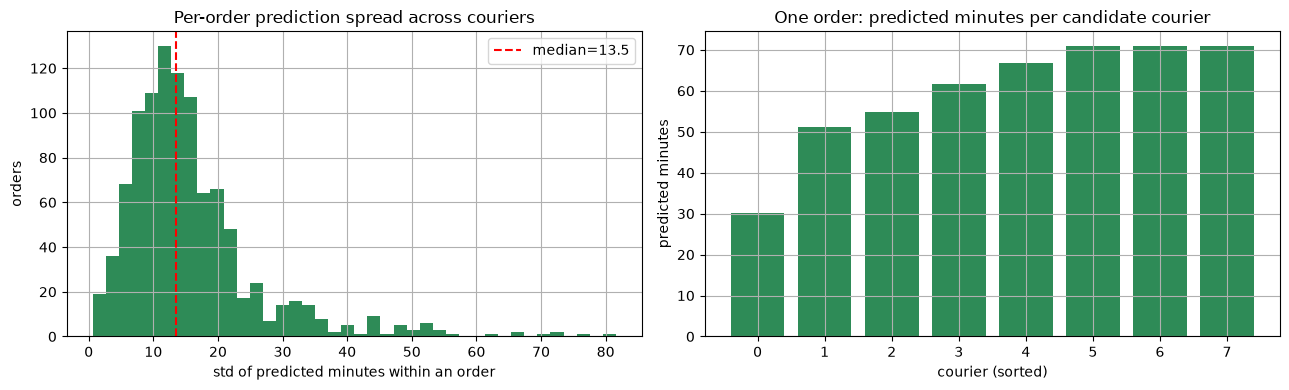

In [8]:
within, ncols, example = [], 0, None
for d in pd.date_range("2022-10-05", "2022-10-25", freq="D"):
    for hh in (9, 11, 15):
        t = pd.Timestamp(d) + pd.Timedelta(hours=hh)
        snap = reconstruct_at(df, t, cfg, default_rolling_avg=model.global_avg, region_id="0")
        if len(snap.couriers) < 3 or len(snap.orders) < 2:
            continue
        frame, cids, oids = build_pair_frame(snap)
        p = model.predict_from_raw(frame, cfg).reshape(len(cids), len(oids))
        within.extend(p.std(axis=0).tolist()); ncols += len(oids)
        if example is None and len(cids) >= 6:
            example = p[:, 0]
within = np.array(within)
print(f"orders sampled = {ncols}")
print(f"within-order std across couriers (min):  median={np.median(within):.1f}  "
      f"mean={within.mean():.1f}  p90={np.quantile(within,.9):.1f}  max={within.max():.1f}")
print(f"median within-order spread = {100*np.median(within)/47.5:.0f}% of the headline MAE (47.5)")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(within, bins=40, color="seagreen")
ax[0].axvline(np.median(within), color="r", ls="--", label=f"median={np.median(within):.1f}")
ax[0].set(title="Per-order prediction spread across couriers",
          xlabel="std of predicted minutes within an order", ylabel="orders"); ax[0].legend()
if example is not None:
    ax[1].bar(range(len(example)), np.sort(example), color="seagreen")
    ax[1].set(title="One order: predicted minutes per candidate courier",
              xlabel="courier (sorted)", ylabel="predicted minutes")
plt.tight_layout(); plt.show()

**Finding.** The spread is **non-trivial**: median per-order std ≈ **13 min**
across couriers (mean ~16, up to ~80), ~28% of the headline MAE — and the example
order ranges ~70→104 min depending on courier. So the cost-matrix columns are **not
near-constant**; the assignment layer *does* have real signal to optimize over
(distance, load, and courier history differentiate couriers).

The honest caveat: that ~13-min discriminating signal is **modest relative to the
model's ~47-min absolute error**, so per-pair predictions are noisy even though much
of that error is common-mode (shared by all couriers on an order, and cancels in the
ranking). The assignment is therefore meaningful but its signal-to-noise is limited
— the lever for better dispatch is *stronger courier-specific features* (live GPS,
queue, traffic), not a smaller window-driven MAE.

## Summary

| Q | Question | Verdict |
|---|----------|---------|
| 1 | `slack_min` knowable at accept? | **Yes** — `window_end` is a preset round-hour deadline (120-min windows); 97.5% of pickups land *before* it. Not leakage. |
| 2 | Heavy tail operational? | **Yes** — longer windows → longer pickups; `slack` drives the target (corr 0.89). |
| 3 | Error vs duration | Best (abs) mid-range; worst (abs) on the long tail (92 min); worst (relative) on short pickups (352% MAPE — over-predicts fast ones). |
| 4 | Cross-courier spread | **~13 min median** per order — real signal, matrix is not degenerate, but modest vs the 47-min MAE. |
| 5 | Feature importance | **`slack_min` + `accept_loc_missing` = 85%** of gain. GPS missingness is the #2 driver — fixing coverage is the highest-leverage data-quality lever. |

## Q5 — Feature importance

Which features does the model actually lean on? XGBoost's gain-based importance measures the average reduction in loss each feature contributes across all its splits — a direct read of how much the model relies on each input.

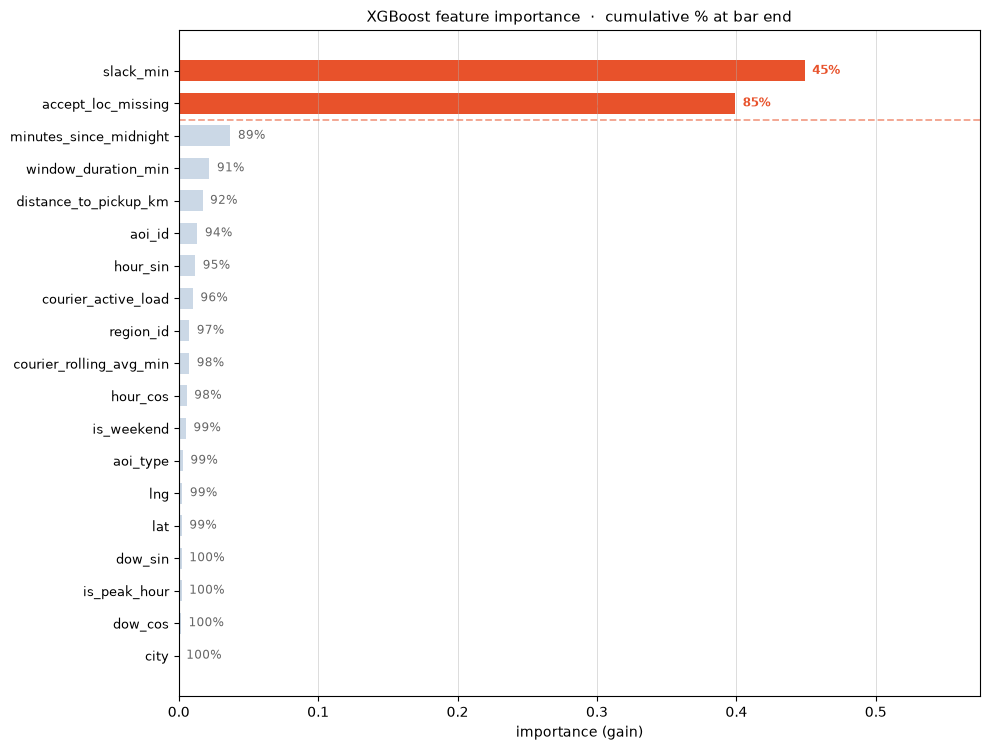

Top 2: slack_min, accept_loc_missing  →  84.8% of total gain
slack_min                  0.4490
accept_loc_missing         0.3991
minutes_since_midnight     0.0371
window_duration_min        0.0221
distance_to_pickup_km      0.0171
aoi_id                     0.0134
hour_sin                   0.0119
courier_active_load        0.0102
region_id                  0.0076
courier_rolling_avg_min    0.0076
hour_cos                   0.0058
is_weekend                 0.0052
aoi_type                   0.0030
lng                        0.0026
lat                        0.0023
dow_sin                    0.0022
is_peak_hour               0.0021
dow_cos                    0.0017
city                       0.0000


In [9]:
fi = pd.Series(
    model.booster.feature_importances_,
    index=model.feature_columns,
    name="gain",
).sort_values(ascending=False)

cumulative = fi.cumsum() / fi.sum()
TOP_N = 2
top_share = cumulative.iloc[TOP_N - 1]

ACCENT = "#E8522B"   # coral — top-2 bars
MUTED  = "#CBD8E6"   # slate-blue — everything else

n = len(fi)
bar_colors = [ACCENT if i < TOP_N else MUTED for i in range(n)]
y_pos = np.arange(n)[::-1]   # index 0 at the top

fig, ax = plt.subplots(figsize=(10, max(5, n * 0.40)))
ax.barh(y_pos, fi.values, color=bar_colors, edgecolor="none", height=0.65)

# cumulative % label at the right end of each bar
for i, (val, cum) in enumerate(zip(fi.values, cumulative.values)):
    ax.text(
        val + fi.max() * 0.012, y_pos[i],
        f"{cum:.0%}",
        va="center", fontsize=8.5,
        color=ACCENT if i < TOP_N else "#666",
        fontweight="bold" if i < TOP_N else "normal",
    )

# dashed separator + annotation beneath top-2
sep_y = y_pos[TOP_N - 1] - 0.5
ax.axhline(sep_y, color=ACCENT, lw=1.3, ls="--", alpha=0.55)
ax.annotate(
    f"top {TOP_N} features → {top_share:.0%} of total model gain",
    xy=(fi.max() * 0.28, sep_y + 0.3),
    fontsize=9.5, color=ACCENT, fontweight="bold",
)

ax.set_yticks(y_pos)
ax.set_yticklabels(fi.index, fontsize=9.5)
ax.set_xlabel("importance (gain)", fontsize=10)
ax.set_title("XGBoost feature importance  ·  cumulative % at bar end", fontsize=11)
ax.set_xlim(0, fi.max() * 1.28)
ax.grid(axis="x", lw=0.5, alpha=0.6)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

print(f"Top {TOP_N}: {', '.join(fi.index[:TOP_N])}  →  {top_share:.1%} of total gain")
print(fi.round(4).to_string())

**Finding.** `slack_min` (45%) and `accept_loc_missing` (40%) together account for **~85%** of the model's total gain — highlighted in coral above. The second feature is a binary flag for missing courier GPS: the model heavily bifurcates on whether it can see the courier's location, treating it almost as a separate prediction regime. `minutes_since_midnight`, `window_duration_min`, and `distance_to_pickup_km` share the next ~8%, while courier history (`courier_rolling_avg_min`, `courier_active_load`) and categorical codes account for the remainder. The implication: improving GPS coverage would likely have a larger impact on accuracy than any other data-quality investment.